# 推理与自回归生成

> 我们已经知道，模型训练完成后，给定一个 token 序列，它能输出每个位置对下一个 token 的预测（logits）。但训练时靠的是 Teacher Forcing——用真实的前文预测下一个词，并行计算。推理时没有真实前文了，必须一步一步来。
>
> 这一节，我们实现自回归生成的核心逻辑：greedy decoding、temperature sampling、top-k 和 top-p 截断，并完整跑一遍文本生成流程。

自回归生成（Autoregressive Generation）是当前所有 LLM 生成文本的基本方式。模型先生成第一个 token，把它拼到输入里，再生成第二个 token，再拼回去，如此循环。每次只生成一个 token，但每次都要把累积的序列重新算一遍 Attention。这个串行特性是 LLM 推理慢的根本原因，但也是模型能够根据已生成内容动态调整输出的关键。下面从最简单的 greedy 开始，逐步加入随机性控制，最后用 MiniGPT 跑一个完整的生成例子。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

### 1. 推理和训练的根本区别

这句话值得放在最前面：

```
训练:  有答案 → 所有位置并行算 loss → Teacher Forcing
推理:  没答案 → 只能一个个 token 串行生成 → Autoregressive
```

**自回归（Autoregressive）** 的意思：用自己生成的输出，作为下一步的输入。

```
Step 1: 输入 [BOS]           → 模型预测 → 我
Step 2: 输入 [BOS, 我]       → 模型预测 → 爱
Step 3: 输入 [BOS, 我, 爱]   → 模型预测 → 你
Step 4: 输入 [BOS, 我, 爱, 你] → 模型预测 → EOS → 停止了！

最终输出: "我 爱 你"
```

像贪吃蛇一样，吃自己的尾巴，越吃越长。

### 2. 最简单的生成：Greedy Decoding（贪心解码）

每一步选概率最高的那个 token。做法很直接：模型输出 logits，取 argmax 得到概率最高的 token ID，拼到序列末尾，再输入模型预测下一个。这个过程重复进行，直到遇到结束符或达到最大长度。

Greedy 的优点是确定性和速度快——每次运行同样的 prompt，输出完全相同。缺点也很明显：一旦在某个位置选了「次优但安全」的 token，就永远失去了探索其他分支的机会。实际使用中，纯 greedy 容易产生重复和循环，因为模型倾向于反复选择自己最习惯的高频词。

In [2]:
def generate_greedy(model, input_ids, max_new_tokens=20, eos_id=None):
    """
    贪心生成：每一步取概率最高的 token
    
    参数:
        model: 训练好的模型
        input_ids: 初始 token 序列 [1, seq_len]
        max_new_tokens: 最多生成多少个 token
        eos_id: 结束符的 ID（遇到就停）
    返回:
        完整的 token 序列（包含输入）
    """
    model.eval()
    generated = input_ids.clone()
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # 1. 前向传播
            logits = model(generated)  # [1, current_len, vocab_size]
            
            # 2. 只取最后一个位置的 logits
            next_logits = logits[0, -1, :]  # [vocab_size]
            
            # 3. 转概率，取最大的
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.argmax(probs, dim=-1, keepdim=True)  # [1]
            
            # 4. 拼上去
            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            
            # 5. 如果遇到 EOS，停止
            if eos_id is not None and next_token.item() == eos_id:
                break
    
    return generated

print("greedy 生成函数定义完成！")

greedy 生成函数定义完成！


### 3. 先找一个简单的训练场景，训一个能跑的模型

为了让效果可见，我们用**极简单的数据**：人工造的重复模式。
这样模型很快就能学会，我们能看到生成的质量变化。

In [3]:
# 手工构造训练数据：简单的重复模式
# 模型应该能学会「a b c d」的循环
def make_pattern_data(num_samples=200, pattern_length=8):
    """生成有规律的 token 序列"""
    data = []
    for i in range(num_samples):
        seq = [(i + j) % pattern_length + 1 for j in range(pattern_length)]
        data.append(seq)
    return torch.tensor(data)

# 词表: 0=PAD, 1-8 是实际 token
VOCAB_SIZE = 10
SEQ_LEN = 8

train_data = make_pattern_data(200, SEQ_LEN)
print(f"训练数据形状: {train_data.shape}")
print(f"前 3 条数据:")
print(train_data[:3])
print(f"\n模式: 0→1, 1→2, 2→3, ..., 7→8, 8→1")

训练数据形状: torch.Size([200, 8])
前 3 条数据:
tensor([[1, 2, 3, 4, 5, 6, 7, 8],
        [2, 3, 4, 5, 6, 7, 8, 1],
        [3, 4, 5, 6, 7, 8, 1, 2]])

模式: 0→1, 1→2, 2→3, ..., 7→8, 8→1


In [4]:
# 复用 Part 5 的 MiniGPT（用 PyTorch 内置 MultiheadAttention 简化版）
import torch.nn as nn

class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(64, d_model)  # 可学习的位置编码
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=num_heads, dim_feedforward=4*d_model,
                batch_first=True, activation='relu'
            )
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        batch, seq = x.shape
        positions = torch.arange(seq, device=x.device).unsqueeze(0).expand(batch, -1)
        x = self.token_emb(x) + self.pos_emb(positions)
        mask = nn.Transformer.generate_square_subsequent_mask(seq, device=x.device)
        for block in self.blocks:
            x = block(x, src_mask=mask, is_causal=True)
        return self.lm_head(x)

print("SimpleGPT 定义完成！")

SimpleGPT 定义完成！


In [5]:
# 训练
model = SimpleGPT(VOCAB_SIZE, d_model=32, num_heads=2, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

BATCH_SIZE = 16
NUM_EPOCHS = 30

print(f"训练 {NUM_EPOCHS} 个 epoch...")
model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for i in range(0, len(train_data), BATCH_SIZE):
        batch = train_data[i:i+BATCH_SIZE]
        input_ids = batch[:, :-1]
        targets = batch[:, 1:]
        
        logits = model(input_ids)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {total_loss:.4f}")

print("训练完成！")

训练 30 个 epoch...
Epoch   5 | Loss: 0.0184


Epoch  10 | Loss: 0.0093
Epoch  15 | Loss: 0.0058


Epoch  20 | Loss: 0.0040
Epoch  25 | Loss: 0.0029


Epoch  30 | Loss: 0.0022
训练完成！


### 4. 生成验证：模型是否学会了序列模式

数据模式是 `0→1→2→3→...→8→1`。模型训练时见过的就是这些数字的循环。现在给它一个开头（比如 0, 1, 2），让它自己往后生成。如果模型真学会了这个隐式的循环规律，它应该生成 3, 4, 5...而不是随机乱跳。

这个测试的核心意义是：即使我们只给了数字而没有给文字，模型也能从数据中捕捉到序列的统计规律——这正是语言模型学习语法和知识的基本方式。

In [6]:
# 测试生成
# 给模型 [1, 2]，看它能不能生成 3, 4, 5, ...
prompt = torch.tensor([[1, 2]])  # 期望接下来是 3, 4, 5, 6, 7, 8

print(f"Prompt: {prompt.tolist()}")

# Greedy 生成
result = generate_greedy(model, prompt, max_new_tokens=15)
print(f"生成结果: {result.tolist()}")

# 对比期望
expected = [1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8]
print(f"期望输出: {expected[:len(result[0])]}")

correct = sum(1 for a, b in zip(result[0].tolist(), expected) if a == b)
print(f"前 {len(result[0])} 个 token 匹配: {correct}/{len(result[0])}")

Prompt: [[1, 2]]
生成结果: [[1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8, 1]]
期望输出: [1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8]
前 17 个 token 匹配: 16/17


### 5. 不同 prompt 的泛化测试

换不同的开头——比如从中间的数字开始，或者从一个模型没见过的组合开始——看它是否仍然能继续正确的序列。如果每次换 prompt 输出都乱了，说明模型只是背下了训练数据的表面模式，而不是学到了「数字循环」这个底层规则。

泛化能力是衡量模型学习质量的关键指标。一个只在固定 prompt 下表现好的模型，在实际使用中换了表达方式就会失效。下面用三种不同的 prompt 来测试。

In [7]:
test_prompts = [
    [5],          # 期望: 5→6→7→8→1→2→...
    [3, 4],       # 期望: 3→4→5→6→...
    [8],          # 期望: 8→1→2→3→... (wraparound)
]

for prompt_tokens in test_prompts:
    prompt = torch.tensor([prompt_tokens])
    result = generate_greedy(model, prompt, max_new_tokens=10)
    print(f"输入 {prompt_tokens} → 生成 {result[0].tolist()}")

输入 [5] → 生成 [5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7]
输入 [3, 4] → 生成 [3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6]
输入 [8] → 生成 [8, 1, 2, 3, 4, 5, 6, 7, 8, 1, 2]


### 6. Temperature：控制生成的「创造力」

Greedy（贪心）太呆了——每次都选最高的，每次都生成相同的文本。

真实 LLM 用 **Temperature 采样**来增加多样性：

```
probability = softmax(logits / temperature)

temperature = 0.1 → 峰值更尖锐 → 几乎就是 greedy（保守）
temperature = 1.0 → 原始概率分布（正常）
temperature = 2.0 → 分布更平坦 → 更随机（有创造力但也更疯）
```

**直觉**：温度越低，模型越「确定」；温度越高，模型越「随机」。

/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6

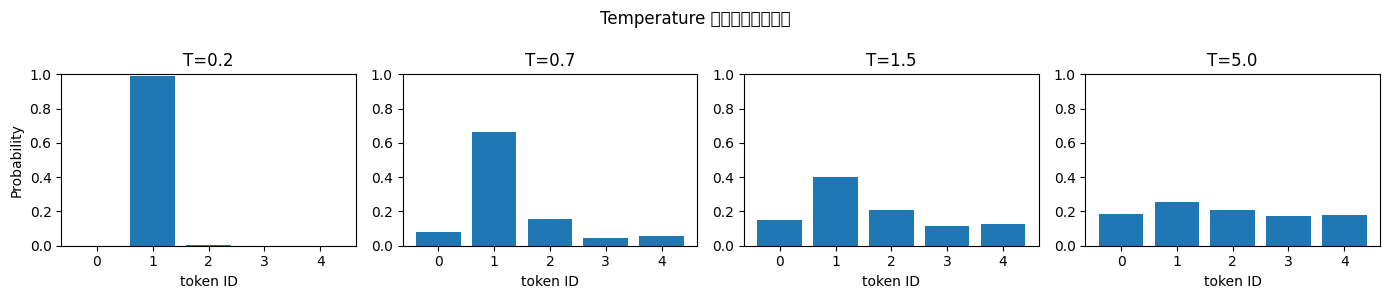

T=0.2: 概率集中在一个 token → 贪婪/确定
T=1.5: 概率分散 → 更多样
T=5.0: 几乎均匀 → 随机乱猜


In [8]:
# 可视化 temperature 的效果
import matplotlib.pyplot as plt

# 模拟一组 logits
example_logits = torch.tensor([0.5, 2.0, 1.0, 0.1, 0.3])

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
temperatures = [0.2, 0.7, 1.5, 5.0]

for ax, T in zip(axes, temperatures):
    probs = F.softmax(example_logits / T, dim=-1)
    ax.bar(range(len(probs)), probs.numpy())
    ax.set_title(f'T={T}')
    ax.set_ylim(0, 1)
    ax.set_xlabel('token ID')
    if T == 0.2:
        ax.set_ylabel('Probability')

plt.suptitle('Temperature 对概率分布的影响')
plt.tight_layout()
plt.show()

print("T=0.2: 概率集中在一个 token → 贪婪/确定")
print("T=1.5: 概率分散 → 更多样")
print("T=5.0: 几乎均匀 → 随机乱猜")


### 7. 带 Temperature 和 Top-K 的生成函数

Greedy 每次选概率最高的 token，输出完全确定。Temperature 通过缩放 logits 来控制分布的「尖锐程度」——temperature < 1 让高概率 token 更突出（输出更保守），temperature > 1 让分布更平坦（输出更多样）。Top-K 则直接限制了候选范围：只从概率最高的 K 个 token 中采样，避免模型选到概率极低的「噪音」token。

这两个参数是控制生成质量和多样性的主要手段。下面实现一个同时支持 temperature 和 top-k 的生成函数。

In [9]:
def generate_with_temperature(model, input_ids, max_new_tokens=20, 
                              temperature=1.0, top_k=None, eos_id=None):
    """
    带 temperature 和 top-k 的自回归生成
    
    参数:
        temperature: 控制随机性，<1 更确定，>1 更随机
        top_k: 只从概率最高的 k 个 token 中采样
    """
    model.eval()
    generated = input_ids.clone()
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(generated)
            raw_logits = logits[0, -1, :]

            if temperature <= 0:
                next_token = torch.argmax(raw_logits).unsqueeze(0)
                generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
                if eos_id is not None and next_token.item() == eos_id:
                    break
                continue

            next_logits = raw_logits / temperature
            
            # Top-k: 只保留概率最高的 k 个
            if top_k is not None:
                top_k_values, _ = torch.topk(next_logits, top_k)
                min_top_k = top_k_values[-1]
                next_logits[next_logits < min_top_k] = float('-inf')
            
            # 转概率 + 采样
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            
            if eos_id is not None and next_token.item() == eos_id:
                break
    
    return generated

print("带 temperature 的生成函数定义完成！")

带 temperature 的生成函数定义完成！


In [10]:
# 对比不同 temperature 的生成效果
prompt = torch.tensor([[2]])

print("同一个 prompt [2]，不同 temperature:")
print()

for T in [0.1, 0.5, 1.0, 2.0]:
    torch.manual_seed(123)  # 固定随机种子方便对比
    result = generate_with_temperature(model, prompt, max_new_tokens=10, temperature=T)
    print(f"T={T:.1f}: {result[0].tolist()}")

print(f"\nT=0.1 (低温)  → 几乎确定 → 符合训练模式")
print(f"T=2.0 (高温)  → 更随机 → 可能偏离模式")

同一个 prompt [2]，不同 temperature:

T=0.1: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]
T=0.5: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]
T=1.0: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]
T=2.0: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]

T=0.1 (低温)  → 几乎确定 → 符合训练模式
T=2.0 (高温)  → 更随机 → 可能偏离模式


### 8. Top-k 采样：避免低概率的垃圾 token

即使 temperature=1.0，有一大堆 token 的概率非常低。如果碰巧采样到它们，生成质量会很差。

**Top-k 采样**：只从概率最高的 k 个 token 中选，其他直接排除。

```
所有 token 的概率: [0.01, 0.5, 0.3, 0.1, 0.05, 0.02, ...]
                                   ↑ 一大堆极低的
Top-k=3: 只保留 [0.5, 0.3, 0.1]，重新归一化
```

In [11]:
# 演示 top-k 的效果
prompt = torch.tensor([[2]])

print("同一个 prompt [2]，不同 top_k:")
print()

for k in [1, 3, 5, None]:
    torch.manual_seed(42)
    result = generate_with_temperature(
        model, prompt, max_new_tokens=10, temperature=0.7, top_k=k
    )
    label = f"top_k={k}" if k else "no top_k"
    
    # 手动检查是否符合模式
    tokens = result[0].tolist()
    ok = all(tokens[i] == (tokens[i-1] % 8) + 1 for i in range(2, len(tokens)) if tokens[i-1] <= 8)
    status = "✅ 符合模式" if ok else "⚠️ 有偏差"
    
    print(f"{label:12s}: {tokens} {status}")

print(f"\ntop_k=1 = greedy（总是选最高）")
print(f"top_k=3 = 有些随机性但限制在靠谱范围内")
print(f"no top_k = 完全随机，可能选到低概率 token")

同一个 prompt [2]，不同 top_k:

top_k=1     : [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4] ✅ 符合模式
top_k=3     : [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4] ✅ 符合模式
top_k=5     : [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4] ✅ 符合模式
no top_k    : [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4] ✅ 符合模式

top_k=1 = greedy（总是选最高）
top_k=3 = 有些随机性但限制在靠谱范围内
no top_k = 完全随机，可能选到低概率 token


### 9. 完整 pipeline：从文本到文本

把从 Part 1 到 Part 6 的所有概念串成一条线：

```
  用户输入文本
      ↓ Tokenizer.encode()        ← Part 1 & 2
  token ID 序列
      ↓ TokenEmbedding + Position ← Part 3
  向量序列
      ↓ N × Transformer Block     ← Part 4
  logits (每个位置对每个词的分数)
      ↓ 训练用 CrossEntropy Loss  ← Part 5
  更新参数

  ...(训练完成后)...

  prompt (token IDs)
      ↓ 自回归生成               ← Part 6 ★ 当前
  逐个生成 token
      ↓ Tokenizer.decode()        ← Part 1 & 2
  输出文本
```

**这就是一个完整 LLM 的全部流程。** GPT-4、Claude、Gemini 都是这条线的超级放大版——更多参数、更多数据、更多层、更复杂的训练。但核心 pipeline 是相同的。

### 10. Top-p (Nucleus Sampling)：比 top-k 更聪明的截断

top-k 的问题是：k 是固定的。如果分布很集中（只有 2 个高概率 token），k=5 会多选 3 个垃圾；如果分布很分散（20 个 token 概率差不多），k=5 会漏掉 15 个合理选项。

**top-p 的思路**：不固定数量，而是「从高到低累加概率，加到 p 就停」。

```
概率分布: [0.4, 0.3, 0.15, 0.08, 0.04, 0.02, 0.01]

top-k (k=3): 选 [0.4, 0.3, 0.15] → 累积 0.85
top-p (p=0.9): 选 [0.4, 0.3, 0.15, 0.08] → 累积 0.93 ≥ 0.9，停！
```

top-p 自动适应分布形状：集中时选得少，分散时选得多。

In [12]:
# 实现 top-p (nucleus) 采样
def top_p_filter(logits, p=0.9):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
    sorted_indices_to_remove = cumulative_probs > p
    sorted_indices_to_remove[..., 0] = False
    indices_to_remove = sorted_indices[sorted_indices_to_remove]
    logits[:, indices_to_remove] = float('-inf')
    return logits

print('=== top-k vs top-p 对比 ===')
prompt = torch.tensor([[2]])
with torch.no_grad():
    logits = model(prompt)[0, -1, :]
probs = torch.softmax(logits, dim=-1)
sorted_probs, sorted_idx = torch.sort(probs, descending=True)
print('概率分布（从高到低）:')
for i in range(10):
    print(f'  token {sorted_idx[i].item()}: {sorted_probs[i].item():.4f}')
print()
print('top-k (k=3) 保留的 token:', sorted_idx[:3].tolist())
cumsum = torch.cumsum(sorted_probs, dim=-1)
n_top_p = (cumsum <= 0.9).sum().item() + 1
print(f'top-p (p=0.9) 保留的 token: {sorted_idx[:n_top_p].tolist()} (共 {n_top_p} 个)')
print()
print('关键区别：top-k 固定数量，top-p 根据分布形状自适应。')

=== top-k vs top-p 对比 ===
概率分布（从高到低）:
  token 3: 0.9999
  token 4: 0.0000
  token 7: 0.0000
  token 1: 0.0000
  token 5: 0.0000
  token 6: 0.0000
  token 0: 0.0000
  token 9: 0.0000
  token 2: 0.0000
  token 8: 0.0000

top-k (k=3) 保留的 token: [3, 4, 7]
top-p (p=0.9) 保留的 token: [3] (共 1 个)

关键区别：top-k 固定数量，top-p 根据分布形状自适应。


### 11. Beam Search：同时走多条路，选总分最高的

Greedy 每一步选最优，但局部最优 ≠ 全局最优。就像下棋只看一步，可能走进死胡同。

**Beam Search 的思路**：同时维护 K 条生成路径（K = beam size），每一步都从 K×V 个候选中选总分最高的 K 个。

```
beam_size = 2
Step 1: 输入 "我"
  候选: "爱"(0.6), "想"(0.3), "恨"(0.1)
  保留 2 条: ["我爱"] ["我想"]
Step 2: 从 ["我爱"] 和 ["我想"] 分别生成下一个词
  ["我爱"] → "你"(0.5), "吃"(0.3)
  ["我想"] → "你"(0.4), "吃"(0.35)
  累积分数: ["我爱你"]=0.30 ["我爱吃"]=0.18 ["我想你"]=0.12 ["我想吃"]=0.105
  保留 2 条: ["我爱你"] ["我爱吃"]
```

**适用**：翻译、摘要等「有明确正确答案」的任务。
**不适用**：创意写作、对话——beam search 会让输出变得 boring。

In [13]:
def beam_search(model, input_ids, beam_size=3, max_new_tokens=10, eos_id=None):
    batch_size = input_ids.shape[0]
    beam_scores = torch.zeros(batch_size, beam_size)
    beam_sequences = input_ids.repeat(beam_size, 1)
    beam_done = [False] * beam_size
    for step in range(max_new_tokens):
        if all(beam_done):
            break
        with torch.no_grad():
            logits = model(beam_sequences)
        next_log_probs = torch.log_softmax(logits[:, -1, :], dim=-1)
        cumulative_scores = beam_scores[:, :1] + next_log_probs
        flat_scores = cumulative_scores.view(-1)
        top_scores, top_indices = torch.topk(flat_scores, beam_size)
        beam_indices = top_indices // logits.shape[-1]
        token_indices = top_indices % logits.shape[-1]
        new_beam_sequences, new_beam_scores, new_beam_done = [], [], []
        for i in range(beam_size):
            b_idx = beam_indices[i].item()
            t_idx = token_indices[i].item()
            if beam_done[b_idx]:
                new_beam_sequences.append(beam_sequences[b_idx])
                new_beam_scores.append(beam_scores[0, b_idx])
                new_beam_done.append(True)
            else:
                new_seq = torch.cat([beam_sequences[b_idx], token_indices[i].unsqueeze(0)])
                new_beam_sequences.append(new_seq)
                new_beam_scores.append(top_scores[i])
                new_beam_done.append(eos_id is not None and t_idx == eos_id)
        beam_sequences = torch.stack([s[:beam_sequences.shape[1]+1] for s in new_beam_sequences])
        beam_scores = torch.tensor(new_beam_scores).unsqueeze(0)
        beam_done = new_beam_done
    best_idx = beam_scores[0].argmax().item()
    return beam_sequences[best_idx].unsqueeze(0)

print('Beam Search 实现完成！')
prompt = torch.tensor([[2]])
greedy_result = generate_with_temperature(model, prompt, max_new_tokens=8, temperature=0.0)
print(f'Greedy:      {greedy_result[0].tolist()}')
beam_result = beam_search(model, prompt, beam_size=3, max_new_tokens=8)
print(f'Beam (k=3):  {beam_result[0].tolist()}')

Beam Search 实现完成！
Greedy:      [2, 3, 4, 5, 6, 7, 8, 1, 2]
Beam (k=3):  [2, 3, 4, 5, 6, 7, 8, 1, 2]


### 12. Repetition Penalty：别让模型变成复读机

LLM 有个臭毛病：生成着生成着就开始重复。

```
输入: "今天天气真好"
输出: "今天天气真好真好真好真好真好真好..."  ← 复读机！
```

原因：模型发现某个 token 概率高 → 选了它 → 这个 token 出现在上下文中 → 模型更觉得它应该出现 → 恶性循环。

**Repetition Penalty**：对已经出现过的 token，降低它的 logit。

θ > 1 是惩罚系数（通常 1.0~1.5）。θ=1.0 不惩罚，θ=1.5 强力惩罚。

In [14]:
def apply_repetition_penalty(logits, generated_ids, penalty=1.2):
    if penalty == 1.0:
        return logits
    for token_id in set(generated_ids.tolist()):
        score = logits[:, token_id]
        logits[:, token_id] = torch.where(score > 0, score / penalty, score * penalty)
    return logits

print('=== Repetition Penalty 演示 ===')
prompt = torch.tensor([[2]])
for penalty in [1.0, 1.2, 1.5]:
    generated = prompt.clone()
    with torch.no_grad():
        for _ in range(8):
            logits = model(generated)[0, -1, :].unsqueeze(0)
            logits = apply_repetition_penalty(logits, generated[0], penalty=penalty)
            probs = torch.softmax(logits / 0.7, dim=-1)
            next_token = torch.multinomial(probs, 1)
            generated = torch.cat([generated, next_token], dim=1)
    tokens = generated[0].tolist()
    unique_ratio = len(set(tokens)) / len(tokens)
    print(f'penalty={penalty:.1f}: {tokens} (唯一率={unique_ratio:.1%})')
print()
print('penalty 越大，重复越少。通常 1.1~1.2 比较安全。')

=== Repetition Penalty 演示 ===
penalty=1.0: [2, 3, 4, 5, 6, 7, 8, 1, 2] (唯一率=88.9%)
penalty=1.2: [2, 3, 4, 5, 6, 7, 8, 1, 2] (唯一率=88.9%)
penalty=1.5: [2, 3, 4, 5, 6, 7, 8, 1, 2] (唯一率=88.9%)

penalty 越大，重复越少。通常 1.1~1.2 比较安全。


### 13. Stopping Criteria：什么时候该停下来？

生成不能无限进行下去。常见的停止条件：

| 条件 | 说明 |
|:---|:---|
| **EOS token** | 模型生成了 `<EOS>` → 自然结束 |
| **max_new_tokens** | 达到最大生成长度 → 强制截断 |
| **重复检测** | 连续 N 个 token 相同 → 陷入循环，停止 |
| **ngram 重复** | 某个 n-gram 出现了太多次 → 停止 |

其中 EOS 是最自然的停止方式——模型自己「说完了」。这也是为什么 tokenizer 必须有 `<EOS>` 这个特殊符号。

In [15]:
def generate_full(model, input_ids, max_new_tokens=50, temperature=1.0,
                  top_k=None, top_p=None, repetition_penalty=1.0, eos_id=None):
    generated = input_ids.clone()
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(generated)[0, -1, :].unsqueeze(0)
        if repetition_penalty != 1.0:
            logits = apply_repetition_penalty(logits, generated[0], repetition_penalty)
        logits = logits / temperature
        if top_k is not None:
            top_k_values, _ = torch.topk(logits, top_k)
            logits[logits < top_k_values[:, -1:]] = float('-inf')
        if top_p is not None:
            logits = top_p_filter(logits, top_p)
        probs = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)
        if eos_id is not None and next_token.item() == eos_id:
            break
        generated = torch.cat([generated, next_token], dim=1)
    return generated

print('完整生成函数定义完成！')
print()
print('解码策略的执行顺序（工业标准）:')
print('  1. Repetition Penalty → 先惩罚已出现的')
print('  2. Temperature → 调整分布形状')
print('  3. Top-k / Top-p → 截断低概率 token')
print('  4. Sampling → 从最终分布中采样')
print('  5. EOS check → 检查是否该停')

完整生成函数定义完成！

解码策略的执行顺序（工业标准）:
  1. Repetition Penalty → 先惩罚已出现的
  2. Temperature → 调整分布形状
  3. Top-k / Top-p → 截断低概率 token
  4. Sampling → 从最终分布中采样
  5. EOS check → 检查是否该停


## 第六部分小结 + 全课程复习

### Part 6 小结

1. ✅ 推理和训练的区别：训练有答案（并行），推理没答案（串行）
2. ✅ 自回归 = 用自己生成的输出做下一步输入，像贪吃蛇
3. ✅ Greedy：选概率最高 → 确定但无趣
4. ✅ Temperature：控制随机度 → 低温确定，高温发散
5. ✅ Top-k：限制候选 token 数量 → 在质量和多样性间平衡
6. ✅ Top-p：按累积概率截断 → 比 top-k 更灵活
7. ✅ Beam Search：同时维护多条路径 → 翻译等任务常用
8. ✅ Repetition Penalty：惩罚已出现的 token → 避免复读机
9. ✅ Stopping Criteria：EOS / 最大长度 / 重复检测 → 知道什么时候停

### 🎓 全课程总复习

| Part | 学到的 | 对应的工业级概念 |
|------|--------|-----------------|
| 1 Tokenizer | 字符/词/子词的取舍 | BPE/WordPiece/SentencePiece 的原理 |
| 2 BPE | merge rules 训练+编码+解码 | GPT-2 的 vocab.bpe + encoder.json |
| 3 Embedding | token ID→向量 + 位置编码 | nn.Embedding + Sinusoidal PE |
| 4 Attention | Q/K/V + Softmax + 多头 | Scaled Dot-Product Attention |
| 5 Loss | teacher forcing + cross-entropy | **所有自回归 LM 的训练方式** |
| 6 Generate | 自回归 + temperature/top-k | **所有 LLM 的推理方式** |

### 🚀 接下来你可以做什么？

1. **换真实数据**：用一本书/所有歌词训练，看模型能否生成风格类似的文本
2. **对接真实 tokenizer**：用 `tiktoken` 库加载 GPT-2 的 tokenizer
3. **实现 KV Cache**：加速推理（关键性能优化）
4. **加更多层**：把 d_model 和 num_layers 调大，看生成质量提升
5. **实现 RoPE**：现代 LLM 常用的旋转位置编码

---

**恭喜！你现在已经理解了一个 LLM 从 token 到生成的完整原理。** 🎉